# Bad Channels

## WAA

In [86]:
# load csv to dataframe
import pandas as pd

df_noise = pd.read_csv('4. WAA CLEANED CODE/bad_channels_noise_significant.csv')
df_speech = pd.read_csv('4. WAA CLEANED CODE/bad_channels_speech_significant.csv')
       

In [87]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

df_combined_waa= pd.concat([df_noise, df_speech], ignore_index=True)
#df_combined= df_speech
# 1. Crear columna grupal para BadChannelProportion
df_combined_waa['BadChannelGroup'] = df_combined_waa['BadChannelProportion'].apply(lambda x: 'High' if x > 0 else 'Low')

rois = df_combined_waa['ROI'].unique()

for roi in rois:
    df_roi = df_combined_waa[df_combined_waa['ROI'] == roi]
    
    # Tabla de contingencia activacion vs grupo bad channel
    contingency_table = pd.crosstab(df_roi['Activation (0/1)'], df_roi['BadChannelGroup'])
    print(f"\nROI: {roi}")
    print(contingency_table)
    
    # Como son siempre 2x2 ahora, podemos hacer Fisher Exact test
    if contingency_table.shape == (2, 2):
        oddsratio, pvalue = fisher_exact(contingency_table)
        print(f"Fisher Exact test p-value: {pvalue:.4f}")
    else:
        # Por si en algún ROI no sale tabla 2x2
        chi2, pvalue, _, _ = chi2_contingency(contingency_table)
        print(f"Chi-cuadrado test p-value: {pvalue:.4f}")



ROI: All_ROIs
BadChannelGroup   High  Low
Activation (0/1)           
0                   11    9
1                   35    9
Fisher Exact test p-value: 0.0703

ROI: Front
BadChannelGroup   Low
Activation (0/1)     
0                  24
1                  40
Chi-cuadrado test p-value: 1.0000

ROI: Left_Auditory
BadChannelGroup   High  Low
Activation (0/1)           
0                    2   21
1                    4   37
Fisher Exact test p-value: 1.0000

ROI: Noise_GLM
BadChannelGroup   Low
Activation (0/1)     
0                  14
1                  50
Chi-cuadrado test p-value: 1.0000

ROI: Noise_WAA
BadChannelGroup   High  Low
Activation (0/1)           
0                    0   15
1                    8   41
Fisher Exact test p-value: 0.1811

ROI: Right_Auditory
BadChannelGroup   High  Low
Activation (0/1)           
0                    1   14
1                    3   46
Fisher Exact test p-value: 1.0000

ROI: Speech_GLM
BadChannelGroup   High  Low
Activation (0/1)           

## GLM

In [92]:
df_noise = pd.read_csv('5. GLM CLEANED CODE/bad_channels_noise_significant.csv')
df_speech = pd.read_csv('5. GLM CLEANED CODE/bad_channels_speech_significant.csv')

In [93]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

df_combined_glm= pd.concat([df_noise, df_speech], ignore_index=True)
#df_combined= df_speech
# 1. Crear columna grupal para BadChannelProportion
df_combined_glm['BadChannelGroup'] = df_combined_glm['BadChannelProportion'].apply(lambda x: 'High' if x > 0 else 'Low')

rois = df_combined_glm['ROI'].unique()

for roi in rois:
    df_roi = df_combined_glm[df_combined_glm['ROI'] == roi]
    
    # Tabla de contingencia activacion vs grupo bad channel
    contingency_table = pd.crosstab(df_roi['Activation (0/1)'], df_roi['BadChannelGroup'])
    print(f"\nROI: {roi}")
    print(contingency_table)
    
    # Como son siempre 2x2 ahora, podemos hacer Fisher Exact test
    if contingency_table.shape == (2, 2):
        oddsratio, pvalue = fisher_exact(contingency_table)
        print(f"Fisher Exact test p-value: {pvalue:.4f}")
    else:
        # Por si en algún ROI no sale tabla 2x2
        chi2, pvalue, _, _ = chi2_contingency(contingency_table)
        print(f"Chi-cuadrado test p-value: {pvalue:.4f}")



ROI: All_ROIs
BadChannelGroup   High  Low
Activation (0/1)           
0                   24    7
1                   22   11
Fisher Exact test p-value: 0.4104

ROI: Back
BadChannelGroup   High  Low
Activation (0/1)           
0                   33   16
1                   13    2
Fisher Exact test p-value: 0.1979

ROI: Front
BadChannelGroup   Low
Activation (0/1)     
0                  38
1                  26
Chi-cuadrado test p-value: 1.0000

ROI: Left
BadChannelGroup   High  Low
Activation (0/1)           
0                    4   23
1                    2   35
Fisher Exact test p-value: 0.2307

ROI: Noise_glm
BadChannelGroup   Low
Activation (0/1)     
0                  11
1                  53
Chi-cuadrado test p-value: 1.0000

ROI: Noise_waa
BadChannelGroup   High  Low
Activation (0/1)           
0                    4   11
1                    4   45
Fisher Exact test p-value: 0.0792

ROI: Right
BadChannelGroup   High  Low
Activation (0/1)           
0                    0 

# Participant's Characteristics

## WAA

In [94]:
# keep only the All ROIs
df_combined_cleaned = df_combined_waa[df_combined_waa['ROI'] == 'All_ROIs']
# drop bad channels column
df_all_ROIS = df_combined_cleaned.drop(columns=['BadChannelProportion', 
                                                        '# Bad Channels', 'Total Channels', 'ROI', 'BadChannelGroup' ])
print(df_all_ROIS)

     Subject  Session  Activation (0/1)
0          1        1                 1
9          1        2                 1
18         2        1                 0
27         2        2                 1
36         3        1                 1
..       ...      ...               ...
531       19        2                 0
540       21        1                 1
549       21        2                 1
558       24        1                 1
567       24        2                 1

[64 rows x 3 columns]


In [95]:
# Define the data as a list of dictionaries
data_part = {
    "Subject": [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    "Skin Type": [2, 2, 1, 2, 4, 2, 3, 3, 2, 2, 2, 2, 2, 2, 3, 1, 2, 1, 2, 2],
    "Hair Color": [2, 3, 1, 0, 3, 1, 3, 3, 1, 3, 1, 1, 2, 2, 0, 1, 1, 3, 1, 3],
    "Hair Thickness": [1, 2, 1, 0, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2, 1, 2, 1],
    "Hair style": [1, 2, 1, 0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 2, 1],
    "Hair Legth": [1, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 0, 1, 2, 2, 2, 2]
}
print(data_part)

{'Subject': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], 'Skin Type': [2, 2, 1, 2, 4, 2, 3, 3, 2, 2, 2, 2, 2, 2, 3, 1, 2, 1, 2, 2], 'Hair Color': [2, 3, 1, 0, 3, 1, 3, 3, 1, 3, 1, 1, 2, 2, 0, 1, 1, 3, 1, 3], 'Hair Thickness': [1, 2, 1, 0, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2, 1, 2, 1], 'Hair style': [1, 2, 1, 0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 2, 1], 'Hair Legth': [1, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 0, 1, 2, 2, 2, 2]}


C:\Users\sarab\AppData\Local\Temp\ipykernel_25208\2975602404.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Skin Type', data=df, palette='pastel', ax=axes[0])
C:\Users\sarab\AppData\Local\Temp\ipykernel_25208\2975602404.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hair style label', data=df, palette='pastel', ax=axes[1])


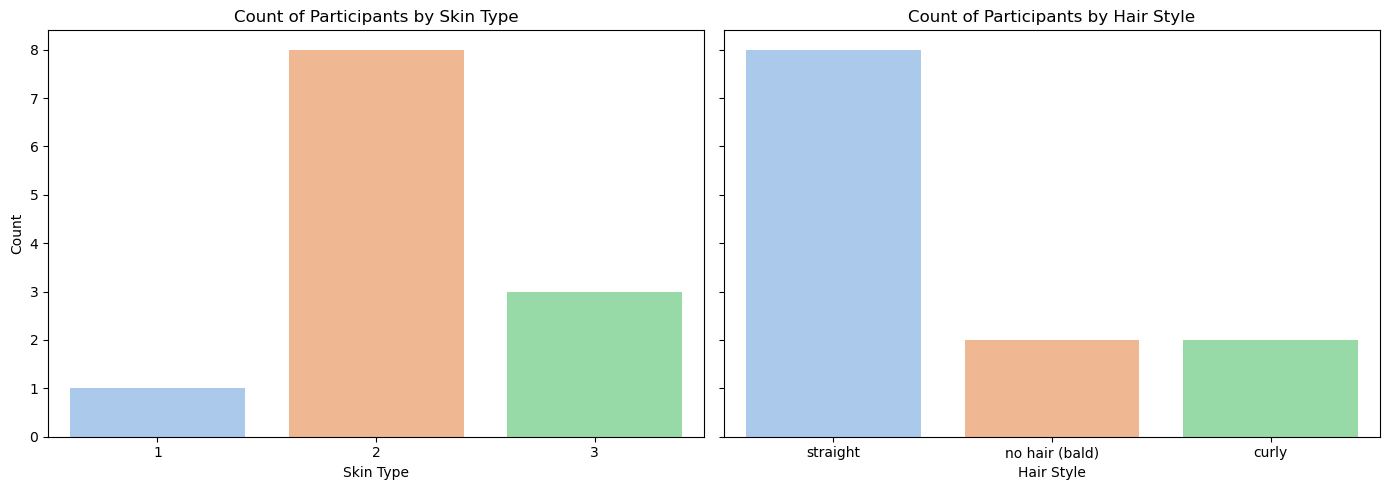

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data
data_part_removed_part = {
    'Subject': [5, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21, 24],
    'Skin Type': [2, 1, 2, 2, 3, 3, 2, 2, 2, 3, 2, 2],
    'Hair Color': [2, 1, 0, 1, 3, 3, 1, 1, 2, 0, 1, 3],
    'Hair Thickness': [1, 1, 0, 1, 2, 2, 1, 1, 1, 0, 2, 1],
    'Hair style': [1, 1, 0, 1, 2, 1, 1, 2, 1, 0, 1, 1],
    'Hair Legth': [1, 2, 0, 2, 1, 2, 2, 2, 1, 0, 2, 2]
}

df = pd.DataFrame(data_part_removed_part)

# Replace Hair Style codes with labels
hair_style_labels = {0: 'no hair (bald)', 1: 'straight', 2: 'curly'}
df['Hair style label'] = df['Hair style'].map(hair_style_labels)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Skin Type subplot
sns.countplot(x='Skin Type', data=df, palette='pastel', ax=axes[0])
axes[0].set_title('Count of Participants by Skin Type')
axes[0].set_xlabel('Skin Type')
axes[0].set_ylabel('Count')

# Hair Style subplot with labels
sns.countplot(x='Hair style label', data=df, palette='pastel', ax=axes[1])
axes[1].set_title('Count of Participants by Hair Style')
axes[1].set_xlabel('Hair Style')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [106]:
# Convert the participant data to a DataFrame
df_part = pd.DataFrame(data_part)

# Merge with df_all_ROIS on 'Subject'
df_all_ROIS_merged = df_all_ROIS.merge(df_part, on='Subject', how='left')

# Drop rows where either 'Skin Type' or 'Hair Color' is missing
df_all_ROIS_clean = df_all_ROIS_merged.dropna(subset=['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth'])

# Optional: convert to integers if needed
df_all_ROIS_clean[['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']] = df_all_ROIS_clean[['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']].astype(int)

# Resulting DataFrame
print(df_all_ROIS_clean.head())

    Subject  Session  Activation (0/1)  Skin Type  Hair Color  Hair Thickness  \
8         5        1                 0          2           2               1   
9         5        2                 1          2           2               1   
10        7        1                 1          1           1               1   
11        7        2                 0          1           1               1   
12        8        1                 1          2           0               0   

    Hair style  Hair Legth  
8            1           1  
9            1           1  
10           1           2  
11           1           2  
12           0           0  


C:\Users\sarab\AppData\Local\Temp\ipykernel_25208\40380239.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_ROIS_clean[['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']] = df_all_ROIS_clean[['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']].astype(int)


In [98]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Example: Check correlation matrix for all pairs of columns
columns = df_all_ROIS_clean.columns.drop(['Subject', 'Session', 'Activation (0/1)'])

cramers_results = pd.DataFrame(index=columns, columns=columns)

for col1 in columns:
    for col2 in columns:
        if col1 == col2:
            cramers_results.loc[col1, col2] = 1.0
        else:
            cramers_results.loc[col1, col2] = cramers_v(df_all_ROIS_clean[col1], df_all_ROIS_clean[col2])

print(cramers_results)


               Skin Type Hair Color Hair Thickness Hair style Hair Legth
Skin Type            1.0   0.478052       0.466031   0.231241   0.175148
Hair Color      0.478052        1.0       0.782976   0.706452   0.901107
Hair Thickness  0.466031   0.782976            1.0   0.708975   0.692071
Hair style      0.231241   0.706452       0.708975        1.0   0.708975
Hair Legth      0.175148   0.901107       0.692071   0.708975        1.0


In [107]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is named df_chars and includes:
# 'Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth'

# Select only numeric characteristic columns
features = ['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']
X = df_all_ROIS_clean[features]

# Standardize the data (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(X_scaled)

# Explained variance ratio per component
print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_)

# Loadings (components)
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(features))], index=features)
print("\nPCA loadings (variable contributions to each component):")
print(loadings)


Explained variance ratio per component:
[0.55031352 0.26800463 0.07594647 0.06996643 0.03576894]

PCA loadings (variable contributions to each component):
                     PC1       PC2       PC3       PC4       PC5
Skin Type       0.047398  0.820919  0.142312 -0.410254 -0.367809
Hair Color      0.480637  0.303582 -0.519207  0.619660 -0.152552
Hair Thickness  0.549683  0.109623 -0.113970 -0.399140  0.716610
Hair style      0.511284 -0.068444  0.802062  0.285587 -0.095087
Hair Legth      0.450754 -0.466077 -0.232120 -0.454797 -0.564689


In [108]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Make a copy and rename columns to avoid spaces
df = df_all_ROIS_clean.copy()
df = df.rename(columns={
    'Activation (0/1)': 'Activation',
    'Skin Type': 'SkinType',
    'Hair style': 'HairStyle'
})

# Make sure data types are appropriate
df['Activation'] = df['Activation'].astype(int)
df['SkinType'] = df['SkinType'].astype(str)  # treat as categorical
df['HairStyle'] = df['HairStyle'].astype(str)

# Fit GEE model
model = smf.gee("Activation ~ C(SkinType) + C(HairStyle)", 
                groups="Subject", 
                data=df, 
                family=sm.families.Binomial())

result = model.fit()
print(result.summary())


                               GEE Regression Results                              
Dep. Variable:                  Activation   No. Observations:                   48
Model:                                 GEE   No. clusters:                       12
Method:                        Generalized   Min. cluster size:                   4
                      Estimating Equations   Max. cluster size:                   4
Family:                           Binomial   Mean cluster size:                 4.0
Dependence structure:         Independence   Num. iterations:                     2
Date:                    ju., 10 jul. 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         11:02:12
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.1344      0.922      0.146      0.884      -1.67

## GLM

In [109]:
# keep only the All ROIs
df_combined_cleaned = df_combined_glm[df_combined_glm['ROI'] == 'All_ROIs']
# drop bad channels column
df_all_ROIS = df_combined_cleaned.drop(columns=['BadChannelProportion', 
                                                        '# Bad Channels', 'Total Channels', 'ROI', 'BadChannelGroup' ])
print(df_all_ROIS)

     Subject  Session  Activation (0/1)
0          1        1                 0
9          1        2                 0
18         2        1                 0
27         2        2                 1
36         3        1                 0
..       ...      ...               ...
531       19        2                 1
540       21        1                 0
549       21        2                 0
558       24        1                 0
567       24        2                 1

[64 rows x 3 columns]


In [110]:
# Convert the participant data to a DataFrame
df_part = pd.DataFrame(data_part)

# Merge with df_all_ROIS on 'Subject'
df_all_ROIS_merged = df_all_ROIS.merge(df_part, on='Subject', how='left')

# Drop rows where either 'Skin Type' or 'Hair Color' is missing
df_all_ROIS_clean = df_all_ROIS_merged.dropna(subset=['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth'])

# Optional: convert to integers if needed
df_all_ROIS_clean[['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']] = df_all_ROIS_clean[['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']].astype(int)

# Resulting DataFrame
print(df_all_ROIS_clean.head())

    Subject  Session  Activation (0/1)  Skin Type  Hair Color  Hair Thickness  \
8         5        1                 1          2           2               1   
9         5        2                 1          2           2               1   
10        7        1                 0          1           1               1   
11        7        2                 1          1           1               1   
12        8        1                 1          2           0               0   

    Hair style  Hair Legth  
8            1           1  
9            1           1  
10           1           2  
11           1           2  
12           0           0  


C:\Users\sarab\AppData\Local\Temp\ipykernel_25208\40380239.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_ROIS_clean[['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']] = df_all_ROIS_clean[['Skin Type', 'Hair Color', 'Hair Thickness', 'Hair style', 'Hair Legth']].astype(int)


In [111]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Make a copy and rename columns to avoid spaces
df = df_all_ROIS_clean.copy()
df = df.rename(columns={
    'Activation (0/1)': 'Activation',
    'Skin Type': 'SkinType',
    'Hair style': 'HairStyle'
})

# Make sure data types are appropriate
df['Activation'] = df['Activation'].astype(int)
df['SkinType'] = df['SkinType'].astype(str)  # treat as categorical
df['HairStyle'] = df['HairStyle'].astype(str)

# Fit GEE model
model = smf.gee("Activation ~ C(SkinType) + C(HairStyle)", 
                groups="Subject", 
                data=df, 
                family=sm.families.Binomial())

result = model.fit()
print(result.summary())


                               GEE Regression Results                              
Dep. Variable:                  Activation   No. Observations:                   48
Model:                                 GEE   No. clusters:                       12
Method:                        Generalized   Min. cluster size:                   4
                      Estimating Equations   Max. cluster size:                   4
Family:                           Binomial   Mean cluster size:                 4.0
Dependence structure:         Independence   Num. iterations:                     2
Date:                    ju., 10 jul. 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         11:04:25
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.7278      0.856      2.019      0.043       0.05